# Loan-to-Income Ratio as a Potential Proxy Channel in HMDA 2017

This notebook explores whether neutral underwriting-related parameters might function as a structural proxy channel in mortgage approval outcomes. To explore this, I use the ratio of loan amount to income amount. 

Using HMDA 2017 nationwide data, I examine:

1. Whether loan-to-income ratios vary systematically across census tracts with different minority population levels.
2. Whether approval rates vary across those same tract categories.
3. Whether higher loan-to-income ratios are associated with lower approval rates.

The goal of this exploration is not to demonstrate discrimination or determine causality, but to investigate whether a neutral financial ratio may transmit structural geographic differences into lending outcomes.

First connect to the location of the csv import tool previously written to handle even very large datasets such as the HMDA dataset.

In [7]:
import sys
from pathlib import Path

CODE_DIR = Path(r"C:\Users\User\OneDrive\Documents\Personal_Projects\sgillihan.github.io\projects\proxy-data-research\code")
assert CODE_DIR.exists(), f"Not found: {CODE_DIR}"

sys.path.insert(0, str(CODE_DIR))
print("Using CODE_DIR:", CODE_DIR)
print("import_csv_from_zip.py exists?", CODE_DIR / "import_csv_from_zip.py")

Using CODE_DIR: C:\Users\User\OneDrive\Documents\Personal_Projects\sgillihan.github.io\projects\proxy-data-research\code
import_csv_from_zip.py exists? C:\Users\User\OneDrive\Documents\Personal_Projects\sgillihan.github.io\projects\proxy-data-research\code\import_csv_from_zip.py


First I am going to set up a small sample (100 rows) from the HMDA data and make sure the anlaysis and logic work. I am going to explore the parameter sensitivity of the ratio of loan amount to applicant income. 

In [15]:
from pathlib import Path
from import_csv_from_zip import load_csv_from_zip
import pandas as pd
import numpy as np


zip_path = Path(r"C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\HMDA\hmda_2017_nationwide_all-records_labels.zip")
csv_NAME = "hmda_2017_nationwide_all-records_labels.csv"

usecols = ["action_taken", "loan_amount_000s", "applicant_income_000s", "minority_population",]

df_100 = load_csv_from_zip(zip_path, csv_filename=csv_NAME, usecols=usecols, nrows=100, low_memory=False)

#print(df_100.shape)
#print(df_100.dtypes)
#df_100.head()

# drop bad values from df
df_100 = df_100[df_100["applicant_income_000s"].notna()]
df_100 = df_100[df_100["applicant_income_000s"] > 0]

#create loan_income_ratio column
df_100["loan_income_ratio"] = df_100["loan_amount_000s"] / df_100["applicant_income_000s"]

#df_100["loan_income_ratio"].describe()

df_100["approved_actual"] = (df_100["action_taken"] == 1)

# group tracts by minority population quartiles
df_100["minority_quartile"] = pd.qcut(df_100["minority_population"], q=4, labels=["Q1_low", "Q2_midlow", "Q3_midhigh", "Q4_high"])

# quick check of approval rates by minority quartile
out = df_100.groupby("minority_quartile").agg(
    n=("approved_actual", "size"),
    approval_rate=("approved_actual", "mean"),
    median_ratio=("loan_income_ratio", "median"),
)
out




C:\Users\User\AppData\Local\Temp\ipykernel_26020\2881057612.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df_100.groupby("minority_quartile").agg(


,n,approval_rate,median_ratio
minority_quartile,,,
Q1_low,24,0.541667,1.563803
Q2_midlow,24,0.458333,2.235987
Q3_midhigh,23,0.391304,2.628571
Q4_high,24,0.333333,3.334667


As the chart above shows, as tract minority population percentage increases, the approval rate decreases and the median loan to income ratio increases. This illustrates data sensitivity to these parameters.

Below, I will run this analysis on the whole csv file (chunked). The code block immediately below loads the 2017 HMDA data into a parqet file.

In [ ]:
zip_path = Path(r"C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\HMDA\hmda_2017_nationwide_all-records_labels.zip")
csv_NAME = "hmda_2017_nationwide_all-records_labels.csv"
out_path = Path(r"C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\HMDA\hmda_2017_nationwide.parquet")

usecols = ["action_taken", "loan_amount_000s", "applicant_income_000s", "minority_population"]

chunks = load_csv_from_zip(zip_path, csv_filename=csv_NAME, usecols=usecols, chunksize=500_000, low_memory=False)

parts = []
total_rows = 0
kept_rows = 0

for i, chunk in enumerate(chunks, start=1):
    total_rows += len(chunk)

    # drop bad values
    chunk = chunk.dropna(subset=["loan_amount_000s", "applicant_income_000s", "minority_population", "action_taken"])
    chunk = chunk[chunk["applicant_income_000s"] > 0]

    # derived columns
    chunk["loan_income_ratio"] = chunk["loan_amount_000s"] / chunk["applicant_income_000s"]
    chunk["approved_actual"] = (chunk["action_taken"] == 1)

    parts.append(chunk)
    kept_rows += len(chunk)

    if i%5 ==0:
        print(f"Chunks processed: {i} | total read: {total_rows} | total kept: {kept_rows}")

df_all = pd.concat(parts, ignore_index=True)

# compute minority quartiles on the full dataset
df_all["minority_quartile"] = pd.qcut(df_all["minority_population"], q=4, labels=["Q1_low", "Q2_midlow", "Q3_midhigh", "Q4_high"])

# save to parquet
out_path.parent.mkdir(parents=True, exist_ok=True)
df_all.to_parquet(out_path, index=False)

print("Saved to:", out_path)
print("Final shape:", df_all.shape)


Chunks processed: 5 | total read: 2500000 | total kept: 2180094
Chunks processed: 10 | total read: 5000000 | total kept: 4338227
Chunks processed: 15 | total read: 7500000 | total kept: 6479198
Chunks processed: 20 | total read: 10000000 | total kept: 8572189
Chunks processed: 25 | total read: 12500000 | total kept: 10587522
Saved to: C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\HMDA\hmda_2017_nationwide.parquet
Final shape: (12121771, 7)


## Data Analysis

Now that the base data set is saved as a parquet with the desired calculated fields, I can begin data analysis. 

Key variables:
- `loan_amount_000s` – Loan amount in thousands of dollars
- `applicant_income_000s` – Reported applicant income in thousands
- `action_taken` – Loan outcome (1 = originated)
- `minority_population` – Percentage of minority population in the census tract

Constructed fields:
- `loan_income_ratio` = loan_amount / applicant_income
- `approved_actual` = (action_taken == 1)
- `minority_quartile` = tract minority percentage grouped into quartiles

## Constructing the Loan-to-Income Ratio

The loan-to-income ratio is defined as:

loan_amount_000s / applicant_income_000s

This ratio approximates the relative leverage of the borrower — how large the requested loan is relative to reported income.

Although HMDA 2017 does not include debt-to-income ratio, this measure captures a related concept of financial burden.

This ratio does not encode race or any other protected class directly. It is considered a neutral financial measure derived from income and loan size. Therefore, the ratio might function as a proxy.

## Grouping Census Tracts by Minority Population

Census tracts are grouped into four equal-sized quartiles based on minority population percentage:

- Q1_low – Lowest minority percentage
- Q4_high – Highest minority percentage

This grouping allows examination of whether financial measures and approval outcomes vary systematically across structural geographic contexts.

In [38]:
PARQUET_PATH = Path(r"C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\HMDA\hmda_2017_nationwide.parquet")
df = pd.read_parquet(PARQUET_PATH, columns=["approved_actual", "loan_income_ratio", "minority_quartile"])

out = df.groupby("minority_quartile").agg(
    n=("approved_actual", "size"),
    approval_rate=("approved_actual", "mean"),
    median_ratio=("loan_income_ratio", "median"),
)
out


C:\Users\User\AppData\Local\Temp\ipykernel_26020\1986090809.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby("minority_quartile").agg(


,n,approval_rate,median_ratio
minority_quartile,,,
Q1_low,3031585,0.600861,2.141732
Q2_midlow,3030228,0.592376,2.388889
Q3_midhigh,3029886,0.569914,2.500000
Q4_high,3030072,0.512799,2.681818


## Observed Structural Pattern

Across 12 million applications:

- Median loan-to-income ratio increases from Q1_low to Q4_high.
- Approval rates decrease from Q1_low to Q4_high.
- The approval gap between lowest and highest minority quartiles is approximately 8.8 percentage points.
- The median loan-to-income ratio differs by approximately 0.54 between Q1 and Q4.

This indicates that a fneutral financial ratio varies systematically across tract demographic contexts, and that those contexts are associated with different approval outcomes.

This does not establish causation, but it demonstrates a plausible proxy transmission channel.

## Relationship Between Loan-to-Income Ratio and Approval

To examine whether the ratio itself is associated with approval likelihood, applications are grouped into quintiles based on loan-to-income ratio (with extreme outliers capped at the 99th percentile).

Approval rates are then compared across these leverage groups.

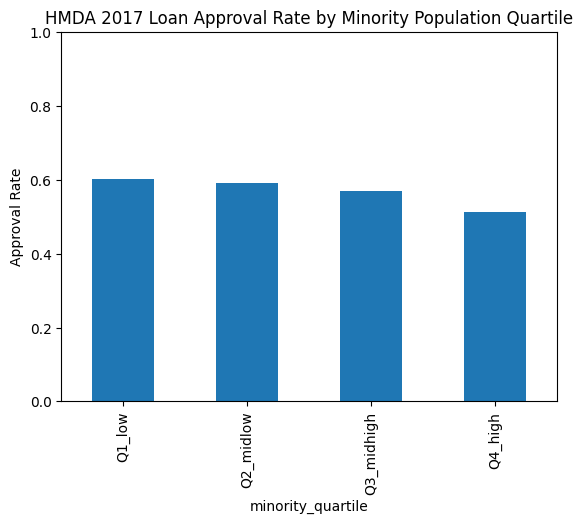

In [39]:
import matplotlib.pyplot as plt
out["approval_rate"].plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("HMDA 2017 Loan Approval Rate by Minority Population Quartile")
plt.ylim(0, 1)
plt.show()

In [42]:
approval_gap = out.loc["Q1_low", "approval_rate"] - out.loc["Q4_high", "approval_rate"]
print("The gap in approval rates between the lowest and highest minority population quartiles is:")
print(approval_gap)

ratio_gap = out.loc["Q4_high", "median_ratio"] - out.loc["Q1_low", "median_ratio"]
print("The gap in median loan-to-income ratio between the lowest and highest minority population quartiles is:")
print(ratio_gap)

The gap in approval rates between the lowest and highest minority population quartiles is:
0.08806157012217597
The gap in median loan-to-income ratio between the lowest and highest minority population quartiles is:
0.5400858983536145


In [43]:
# cap the loan_income_ratio at the 99th percentile to reduce outliers
cap = df["loan_income_ratio"].quantile(0.99)
df_cap = df[df["loan_income_ratio"] <= cap].copy()

df_cap.groupby(pd.qcut(df_cap["loan_income_ratio"], 5))["approved_actual"].mean()

C:\Users\User\AppData\Local\Temp\ipykernel_26020\793180072.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cap.groupby(pd.qcut(df_cap["loan_income_ratio"], 5))["approved_actual"].mean()


loan_income_ratio
(-0.00099788, 1.282]    0.557677
(1.282, 2.053]          0.581308
(2.053, 2.759]          0.594068
(2.759, 3.676]          0.591842
(3.676, 7.917]          0.538356
Name: approved_actual, dtype: float64

## Conclusion

This analysis demonstrates:

1. Loan-to-income ratios differ across census tract minority population levels.
2. Approval rates differ across those same tract categories.
3. Higher loan-to-income ratios are associated with lower approval probabilities.

Taken together, these findings illustrate how a neutral financial ratio may function as a structural proxy channel — transmitting geographic and socioeconomic differences into lending outcomes when converted into approval decisions.

This notebook does not prove discriminatory intent or causal mechanisms. It provides a bounded empirical demonstration of how proxy channels can arise in mortgage lending data.